In [44]:
import pandas as pd 
import seaborn as sns
from sklearn.impute import SimpleImputer

In [45]:
df = pd.read_csv('../data/raw/smartcart_customers.csv')

In [46]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [48]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [49]:
imp = SimpleImputer(strategy='median')
df['Income'] = imp.fit_transform(df[['Income']])

In [50]:
# Creating AGE from Year_birth
df['Age'] = 2026 - df['Year_Birth']

In [51]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'],dayfirst=True)
reference_date = df['Dt_Customer'].max()

In [52]:
df['Tenure_Days'] = (reference_date-df['Dt_Customer']).dt.days

In [53]:
df['Tenure_Days']

0       663
1       113
2       312
3       139
4       161
       ... 
2235    381
2236     19
2237    155
2238    156
2239    622
Name: Tenure_Days, Length: 2240, dtype: int64

In [54]:
df['Total_Spending'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts']+df[ 'MntFishProducts']+df['MntSweetProducts']+df[ 'MntGoldProds']

In [55]:
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

In [56]:
df['Education'] = df['Education'].replace({
    'Basic':'Undergraduate',
    '2n Cycle':'Undergraduate',
    'Graduation':'Graduate',
    'PhD':'Postgraduate',
    'Master':'Postgraduate'
})


In [57]:
df['Living_With'] = df['Marital_Status'].replace({
    'Married':'Partner',
    'Together':'Partner',
    'Single':'Alone',
    'Divorced':'Alone',
    'Widow':'Alone',
    'Absurd':'Alone',
    'YOLO':'Alone'
})


In [58]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Tenure_Days', 'Total_Spending',
       'Total_Children', 'Living_With'],
      dtype='str')

In [59]:
df = df.drop(columns=[
    'ID','Year_Birth','Marital_Status','Kidhome','Teenhome','Dt_Customer',
    'MntWines','MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds',
])

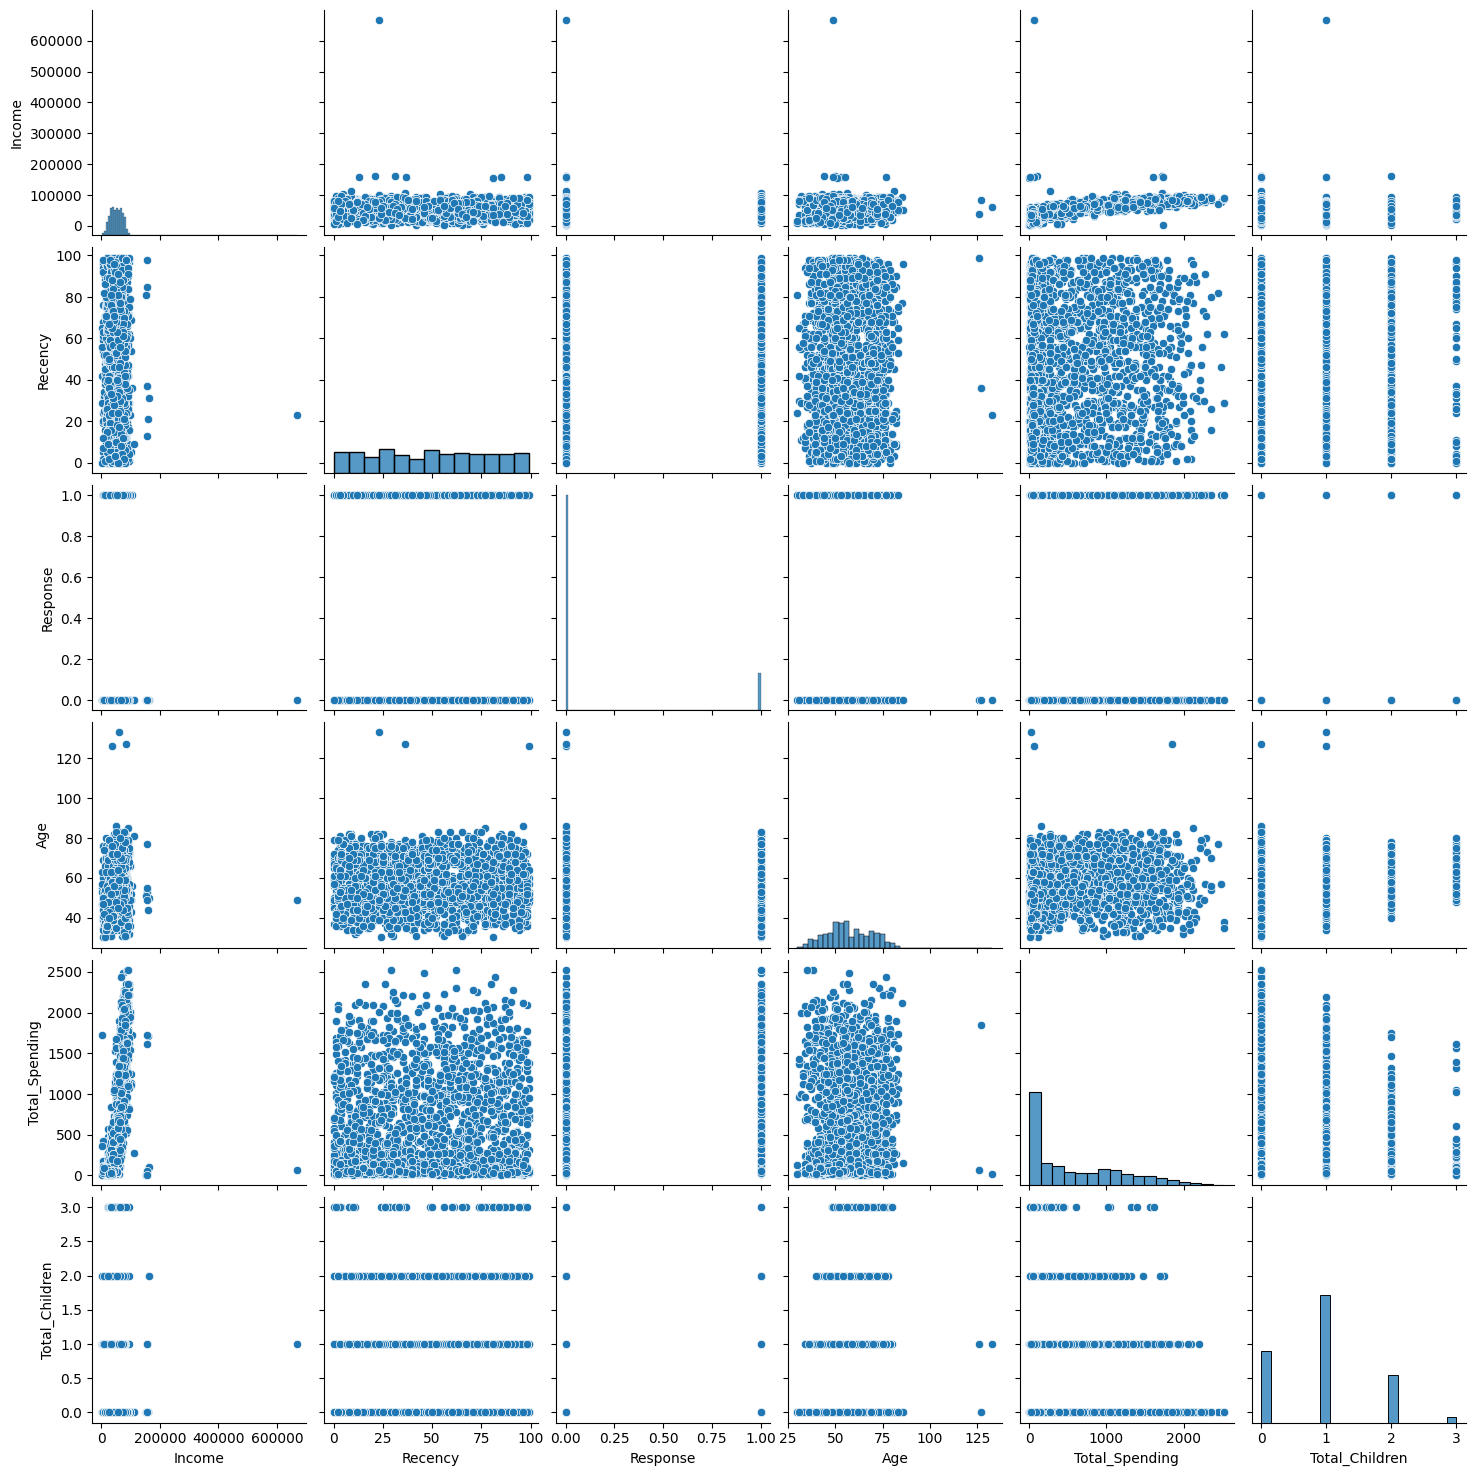

In [60]:
# Outlier Detection
cols = ['Income','Recency','Response','Age','Total_Spending','Total_Children']
sns.pairplot(df[cols])

2 Clear Outliers are the one with Income > 600000 point and The three points in age 

In [61]:
print("Data size before removing outliers", len(df))
df = df[df['Age'] < 90]
df = df[df['Income'] < 600000]
print("Data size after removing outliers", len(df))


Data size before removing outliers 2240
Data size after removing outliers 2236


<Axes: >

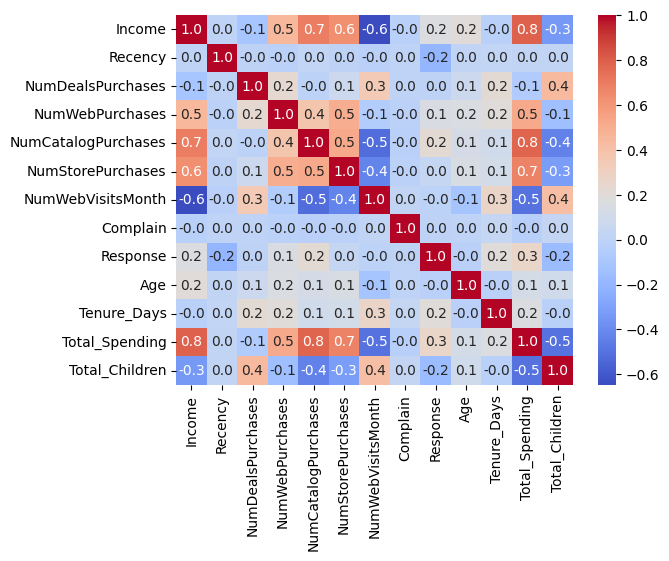

In [62]:
sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm',
    annot=True,
    fmt='.1f'
)

In [63]:
df.to_csv('../data/processed/df_cleaned.csv',index=False)